# Week 1 - Exercise 1 : Torque Dip Analysis (Angle Sweep)

## Background

`Week1_ex1_angle_sweep.ipynb` swept the coil rotation angle (`rot_angle`) from 0 deg to 345 deg in 15 deg steps and extracted the torque at each point. The result broadly follows the sin(theta) trend expected from a coil rotating relative to a magnetic field, but a sharp, symmetric dip appears exactly at 90 deg and 270 deg.

## Purpose of this notebook

This notebook documents the diagnostic process used to determine whether the dip at 90/270 deg is:

- a numerical / mesh convergence artifact, or
- a real physical effect arising from the coil-magnet geometry.

Two hypotheses are tested in turn, with one rejected and one confirmed, based on quantitative evidence (mesh statistics, convergence data) and visual evidence (B-field plots).

## 1. Reproducing the First Result

Load the torque-vs-angle data exported from `Week1_ex1_angle_sweep.ipynb` and re-plot it alongside a simple sin(theta) reference curve, scaled to match the peak torque. This highlights where the simulated curve departs from the idealized shape.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Week1_ex1_angle_sweep_result.csv")
df.head()

,angle_deg,Torque_uNm
0,0.0,-0.452057
1,15.0,7.576077
2,30.0,15.613391
3,45.0,28.287219
4,60.0,49.894582


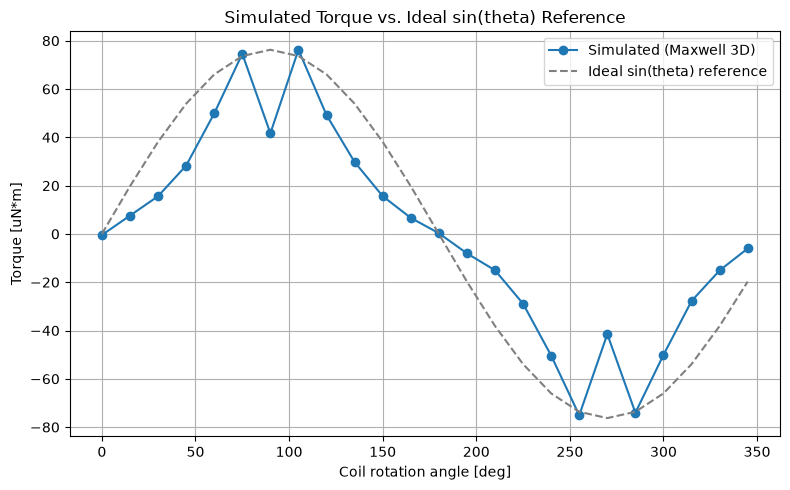

In [2]:
## Overlay simulated torque against an idealized sin(theta) reference ##

theta = np.deg2rad(df["angle_deg"])
peak_torque = df["Torque_uNm"].max()
sin_ref = peak_torque * np.sin(theta)

plt.figure(figsize=(8, 5))
plt.plot(df["angle_deg"], df["Torque_uNm"], marker="o", label="Simulated (Maxwell 3D)")
plt.plot(df["angle_deg"], sin_ref, linestyle="--", color="gray", label="Ideal sin(theta) reference")
plt.xlabel("Coil rotation angle [deg]")
plt.ylabel("Torque [uN*m]")
plt.title("Simulated Torque vs. Ideal sin(theta) Reference")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Images/Week1_ex1_angle_sweep_vs_sin_reference.png", dpi=150)
plt.show()

**Observation**: the simulated curve tracks the sin(theta) reference reasonably well from 0 deg up to about 75 deg, but shows a sharp, symmetric dip right at 90 deg (and again at 270 deg) that the ideal reference does not predict. Two candidate explanations were investigated: (1) insufficient mesh convergence at those specific angles, and (2) a genuine geometric effect from the coil-magnet arrangement.

## 2. Hypothesis 1 - Insufficient Mesh Convergence at 90 deg

**Initial hypothesis**: the adaptive mesh solver may have converged prematurely at 90 deg/270 deg, under-resolving the field in that region and producing an artificially low torque value.

### 2.1 Convergence data at neighboring angles

Convergence tables were pulled from the AEDT Solutions window (Setup1 -> Convergence) for several angles around the dip, using the default solver settings (Minimum Passes = 2, Maximum Passes = 10, target Energy Error = 1%).

In [3]:
## Convergence summary collected from AEDT GUI (Setup1 -> Convergence tab) ##

convergence_summary = pd.DataFrame({
    "angle_deg":         [45,     60,     75,     90],
    "completed_passes":  [9,      9,      8,      7],
    "final_tetrahedra":  [17579,  17744,  14034,  10496],
    "final_energy_error_pct": [None, None, 0.90, 0.72],
    "torque_uNm":        [28.29,  49.895, 74.587, 41.663],
})
convergence_summary

,angle_deg,completed_passes,final_tetrahedra,final_energy_error_pct,torque_uNm
0,45,9,17579,NaN,28.290
1,60,9,17744,NaN,49.895
2,75,8,14034,0.90,74.587
3,90,7,10496,0.72,41.663


**Observation**: 90 deg converged with the *fewest* tetrahedra (10,496) and the *fewest* passes (7) of the four angles, and its global Energy Error (0.72%) was comfortably within the 1% target. On its face this could support the mesh-convergence hypothesis, since the solver stopped earliest right at the dip.

However, the global Energy Error is a domain-averaged metric and could mask a locally under-resolved region near the coil, so this was tested directly rather than inferred from a single number.

### 2.2 Decisive test: force extra passes at 90 deg

The 90 deg variation was re-solved with **Minimum Number of Passes forced to 10** (equal to the Maximum), guaranteeing the solver could not stop early. If the dip were a meshing artifact, the extra refinement should measurably change the torque.

In [4]:
## Before vs. after forcing 10 full adaptive passes at rot_angle = 90 deg ##

mesh_test = pd.DataFrame({
    "condition":        ["Default (stopped at Pass 7)", "Forced minimum 10 passes"],
    "tetrahedra":       [10496, 23092],
    "energy_error_pct": [0.72, 0.237],
    "torque_uNm":       [41.663, 41.764],
})
mesh_test

,condition,tetrahedra,energy_error_pct,torque_uNm
0,Default (stopped at Pass 7),10496,0.720,41.663
1,Forced minimum 10 passes,23092,0.237,41.764


**Result**: forcing the solver through 10 full passes more than doubled the mesh density (10,496 -> 23,092 tetrahedra) and reduced the Energy Error to roughly a third of its previous value (0.72% -> 0.237%), yet the torque changed by only 0.1 uN*m (41.663 -> 41.764) - well within numerical noise.

### 2.3 Conclusion: Hypothesis 1 rejected

Mesh refinement has essentially no effect on the torque value at 90 deg. **The dip is not caused by insufficient mesh convergence.**

## 3. Hypothesis 2 - Coil-Magnet Geometric Symmetry at 90/270 deg

**Revised hypothesis**: since this model uses a single, spatially fixed permanent magnet block (`NdFe35`, created with `create_box` and never rotated) rather than a uniform background field, the torque should depend on the *relative geometric alignment* between the coil and the magnet - not purely on angle in the idealized sin(theta) sense. At exactly 90 deg and 270 deg, the coil axis becomes collinear with a principal axis of the magnet, producing a left-right symmetric arrangement that a simple sin(theta) model does not capture.

### 3.1 Visual comparison: B-field vector plots (Top view)

A `B_Vector` field plot (Fields -> B -> B_Vector, over `AllObjects`) was generated for `rot_angle = 45 deg` and `rot_angle = 90 deg`, viewed from directly above (Orient -> Top) to remove perspective distortion.

*(Insert the two Top-view B_Vector screenshots here: `Images/B_Vector_45deg_top.png` and `Images/B_Vector_90deg_top.png`)*

![B field at 45 deg](Images/B_Vector_45deg_top.png)
![B field at 90 deg](Images/B_Vector_90deg_top.png)

**Observations from the field plots**:

| | 45 deg | 90 deg |
|---|---|---|
| Coil orientation relative to X axis | Diagonal, asymmetric | Exactly parallel / axis-aligned |
| Coil position relative to Y axis | Off-center | Bisected symmetrically by the Y axis |
| B field distribution along coil | Stronger at one end, weaker at the other | Strong and roughly symmetric at both ends |
| Max \|B\| | 1289.3 mT | 1328.0 mT (comparable) |

At 45 deg the coil sits asymmetrically with respect to the fixed magnet, so one "arm" of the coil sits closer to the magnet than the other, giving a large net torque contribution. At 90 deg the coil becomes exactly symmetric about the magnet's axis, so the torque contributions from the two arms of the coil act in a way that partially cancels, producing a local minimum even though the field magnitude itself is not reduced.

### 3.2 Conclusion: Hypothesis 2 confirmed

The dip is a **real geometric effect**, not a numerical artifact. It arises because this model uses a spatially localized permanent magnet rather than a uniform field, so the sin(theta) approximation - which assumes a uniform background field - breaks down precisely at the angles where the coil-magnet arrangement becomes symmetric (90 deg, 270 deg).

## 4. Final Conclusion

| Hypothesis | Status | Evidence |
|---|---|---|
| Insufficient mesh convergence | **Rejected** | Forcing 10 full adaptive passes (2x mesh density, 3x lower Energy Error) changed torque by only 0.1 uN*m |
| Coil-magnet geometric symmetry | **Confirmed** | Top-view B-field plots show the coil becomes exactly axis-aligned/symmetric with the fixed magnet at 90/270 deg |

**Takeaway**: the ideal sin(theta) torque profile assumes a uniform background magnetic field. This model instead uses a single localized permanent magnet, so the torque additionally depends on the relative geometric alignment between the coil and the magnet. At the specific angles where that alignment becomes symmetric (90 deg, 270 deg), the torque contributions from the two halves of the coil partially cancel, producing a local dip that a uniform-field sin(theta) model cannot predict. This is a modeling-fidelity insight rather than a simulation error.